# Recalculating Coastal Upwelling Transport Index (CUTI), Jacox et al., (2018)

For CUTI we need the Ekman net contribution ($Ek_{int}$) + the geostrophic part ($U_{geo}$)

* For the $Ek_{int}$ we integrate the boundaries at every 1 degree perimeter, let the equations be as follow:

\
\begin{aligned}
Q^{(E)}_{E} &= \int_{y_1}^{y_2} U_E(x_E,y)\,dy, = 0 \\
Q^{(W)}_{E} &= - \int_{y_1}^{y_2} U_E(x_W,y)\,dy, \\
Q^{(N)}_{E} &= \int_{x_W}^{x_E} V_E(x,y_2)\,dx, \\
Q^{(S)}_{E} &= - \int_{x_W}^{x_E} V_E(x,y_1)\,dx, \\
Q_{\mathrm{div}}
&= Q^{(E)}_{E} + Q^{(W)}_{E} + Q^{(N)}_{E} + Q^{(S)}_{E}
= \iint\limits_{A} \nabla \!\cdot\! \mathbf{M}_E \, dA, \\
\bar{w}_E
&= \frac{Q_{\mathrm{div}}}{A}
= \frac{1}{\rho\,f}\, \bigl(\nabla \times \boldsymbol{\tau}\bigr)_z .
\end{aligned}

* For geostrophic transport ($U_{geo}$), $\Delta \mathrm{SSH}$ is the difference between the coastal SSH values at the northernmost and southernmost grid points within the 1° segment. The $MLD$ is defined as the width of the Rossby radius of deformation (30 km; R1).

$$
\begin{aligned}
u_{\mathrm{geo}} &= \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}, \\[1ex]
\mathbf{U}_{\mathrm{geo}} &= \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}, \\[1ex]
\text{CUTI} &= U_{\text{ek}} + U_{\text{geo}} \\
&= \frac{\nabla \tau}{\rho_w f} \cdot \hat{k} - \frac{gD}{f} \frac{\partial \eta}{\partial y}.
\end{aligned}
$$

where $g$ is the gravitational acceleration, $D$ is the Ekman layer depth, and $d$ is distance to the coast.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from matplotlib.colors import TwoSlopeNorm 
import matplotlib.colors as mcolors
from tqdm import tqdm 

## Functions

In [2]:
##Normalize
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

## seasonality
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

def monthly_anomaly(da, dim=('lat','lon')):
    """
    Compute monthly climatological anomalies from a DataArray.
    
    Parameters:
    - da: xarray.DataArray with dimensions including 'time' and the spatial dim to average over
    - dim: spatial dimension to average over (e.g., 'lat')
    
    Returns:
    - anomaly: xarray.DataArray with monthly anomalies (same time dimension as input)
    """
    # Step 1: mean over the spatial dimension
    da_mean = da.mean(dim=dim, skipna=True)
    
    # Step 2: compute monthly climatology (climatological mean per month)
    monthly_clim = da_mean.groupby('time.month').mean(dim='time')
    
    # Step 3: subtract climatology to get anomaly
    anomaly = da_mean.groupby('time.month') - monthly_clim

    return anomaly

In [3]:
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))

/tmp/ipykernel_381119/2813671004.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


In [4]:
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [5]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK100km.kml"
R1 = kml2struct(arch_kml_zona1)

MLD_30km = "../../NHCS/Processed/MLD30km.kml"
mld_R = kml2struct(MLD_30km)
# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

lonMLD = mld_R[0]['Lon']
latMLD = mld_R[0]['Lat']

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))
polygon2 = Path(np.column_stack((lonMLD, latMLD)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)
mask_mld = polygon2.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)
mld_30km_mask = np.where(mask_mld, 1, np.nan)

## Data

In [6]:
#--- winds
new_w = loadmat("../../NHCS/Processed/new_winds.mat")

winds_ds = xr.Dataset(
    data_vars={
        'u10': (("time", "lat","lon"), new_w['uwind'].transpose(2, 1, 0)),
        'v10':(("time", "lat","lon"), new_w['vwind'].transpose(2, 1, 0))
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

winds_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    u10      (time, lat, lon) float64 1GB 1.432 1.435 1.439 ... nan nan nan
    v10      (time, lat, lon) float64 1GB -0.9696 -0.999 -1.031 ... nan nan nan

In [7]:
ws = np.sqrt(winds_ds.u10**2 + winds_ds.v10**2)
omega = 7.29e-5
f = 2 * omega * np.sin(np.radians(winds_ds.lat))
pa = 1.22
cd = 1.3e-3
taux = pa * cd * ws * winds_ds.u10
tauy = pa * cd * ws * winds_ds.v10


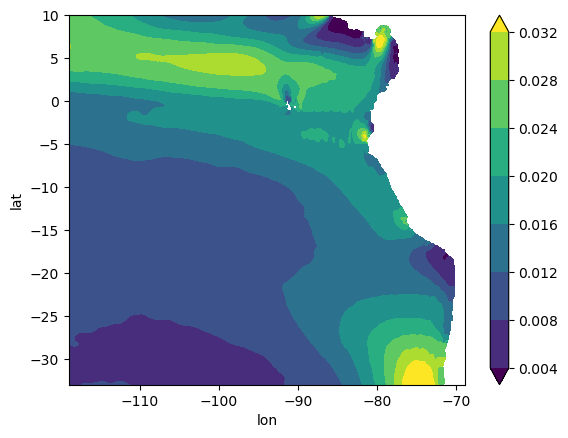

In [8]:
tauy.std('time').plot.contourf(robust=True)
# taux.std('time').plot(robust=True)

In [9]:
rho_sw = 1025

Uek = tauy / (rho_sw * f)
Vek = taux / (rho_sw * f)
# BUI.to_netcdf('BUI.nc')

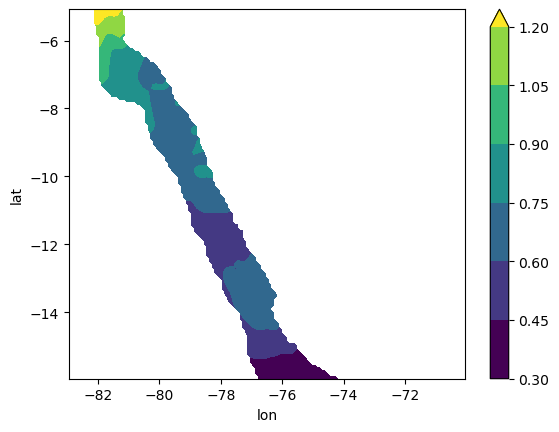

In [10]:
(Uek*inshore_mask).sel(lat=slice(-16,-5),lon=slice(-83,-70)).std('time').plot.contourf(robust=True)

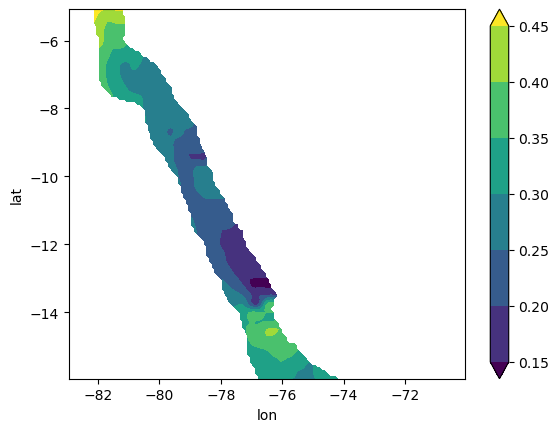

In [11]:
(Vek*inshore_mask).sel(lat=slice(-16,-5),lon=slice(-83,-70)).std('time').plot.contourf(robust=True)

In [12]:
Uek_ = (Uek*inshore_mask).isel(time=0).sel(lat=slice(-16,-5),lon=slice(-83,-70))
Vek_ = (Vek*inshore_mask).isel(time=0).sel(lat=slice(-16,-5),lon=slice(-83,-70))


In [13]:
# Boolean mask of valid ocean cells
valid = xr.where(np.isfinite(Uek_), 1, 0)

# Shift mask in 4 directions
# valid_n = valid.shift(lat=-1)  # neighbor to the north
# valid_s = valid.shift(lat=+1)  # south
valid_e = valid.shift(lon=-1)  # east
valid_w = valid.shift(lon=+1)  # west

west_mask = (valid == 1) & (valid_w == 0)
east_mask = (valid == 1) & (valid_e == 0)

easternmost = Uek_.where(east_mask) #inshore
westernmost = Uek_.where(west_mask) #offshore

southernmost = Vek_.min(dim='lat', skipna=True)
northernmost = Vek_.max(dim='lat', skipna=True)

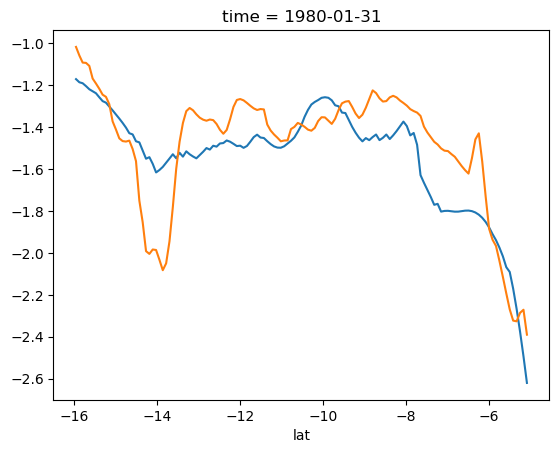

In [14]:
westernmost.mean('lon').plot()
easternmost.mean('lon').plot()

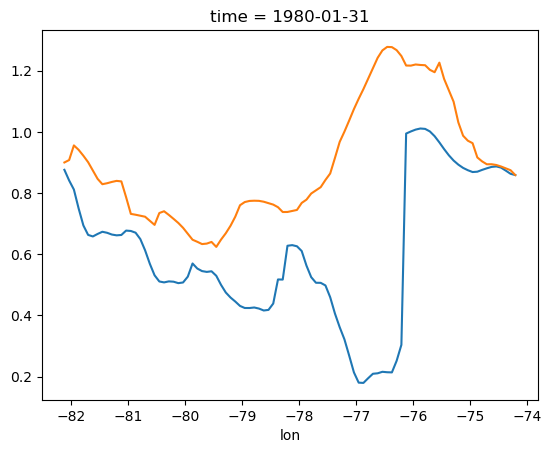

In [15]:
southernmost.plot()
northernmost.plot()

In [16]:
## Calculating Qdiv

Uek_ = (Uek*inshore_mask).isel(time=0).sel(lat=slice(-16,-5),lon=slice(-83,-70))
Vek_ = (Vek*inshore_mask).isel(time=0).sel(lat=slice(-16,-5),lon=slice(-83,-70))

# Boolean mask of valid ocean cells
valid = xr.where(np.isfinite(Uek_), 1, 0)

valid_e = valid.shift(lon=-1)  # east
valid_w = valid.shift(lon=+1)  # west

west_mask = (valid == 1) & (valid_w == 0)
east_mask = (valid == 1) & (valid_e == 0)

easternmost = Uek_.where(east_mask) #inshore
westernmost = Uek_.where(west_mask) #offshore

southernmost = Vek_.min(dim='lat', skipna=True)
northernmost = Vek_.max(dim='lat', skipna=True)

N = 12 #1/12 degree resolution, 12 points per 1 degree
delta_y = 9000 #9km uniform spacing aprox -- change later
# L = 111000 #1 degree

QE = (easternmost.mean('lon')
 .rolling(lat=2,center=False)
 .mean(skipna=True).sum(dim='lat') * delta_y)

QW = -(westernmost.mean('lon')
 .rolling(lat=2,center=False)
 .mean(skipna=True).sum(dim='lat') * delta_y)

QN = (northernmost
 .rolling(lon=2,center=False)
 .mean(skipna=True).sum(dim='lon') * delta_y)

QS = -(southernmost
 .rolling(lon=2,center=False)
 .mean(skipna=True).sum(dim='lon') * delta_y)

(QE + QW + QS + QN)/(delta_y * (N-1))

# easternmost.mean('lon')

<xarray.DataArray ()> Size: 8B
array(3.16904048)
Coordinates:
    time     datetime64[ns] 8B 1980-01-31

## Lets make it a function

In [17]:
Uek_ = (Uek*inshore_mask).isel(time=0).sel(lat=slice(-16,-5),lon=slice(-83,-70))
Vek_ = (Vek*inshore_mask).isel(time=0).sel(lat=slice(-16,-5),lon=slice(-83,-70))

def qdiv_for_band(Uek, Vek, inshore_mask,
                  lat_south, lat_north,   # e.g. -5, -4  (south < north)
                  lon_west=-83, lon_east=-70,
                  delta_y=9250, delta_x=9250, N=12):
    """
    Compute Qdiv for a given lat band [lat_south, lat_north]
    using your current method.
    """

    # slice: note lat_south < lat_north
    Uek_ = (Uek * inshore_mask).sel(
        lat=slice(lat_south, lat_north), lon=slice(lon_west, lon_east)
    )
    Vek_ = (Vek * inshore_mask).sel(
        lat=slice(lat_south, lat_north), lon=slice(lon_west, lon_east)
    )

    # Boolean mask of valid ocean cells
    valid = xr.where(np.isfinite(Uek_), 1, 0)

    valid_e = valid.shift(lon=-1)  # east neighbour
    valid_w = valid.shift(lon=+1)  # west neighbour

    west_mask = (valid == 1) & (valid_w == 0)
    east_mask = (valid == 1) & (valid_e == 0)

    easternmost = Uek_.where(east_mask)   # inshore
    westernmost = Uek_.where(west_mask)   # offshore

    southernmost = Vek_.min(dim='lat', skipna=True)
    northernmost = Vek_.max(dim='lat', skipna=True)

    # QE, QW, QN, QS exactly as you wrote
    QE = (easternmost.mean('lon')
          .rolling(lat=2, center=False)
          .mean(skipna=True).sum(dim='lat') * delta_y) ## as this value points to the coastal boundary it should be 0

    QW = -(westernmost.mean('lon')
           .rolling(lat=2, center=False)
           .mean(skipna=True).sum(dim='lat') * delta_y) ## points to the left

    QN = (northernmost
          .rolling(lon=2, center=False)
          .mean(skipna=True).sum(dim='lon') * delta_y)

    QS = -(southernmost
           .rolling(lon=2, center=False)
           .mean(skipna=True).sum(dim='lon') * delta_y) #points south
    
    Qdiv = (QW + QS + QN) / (delta_x * (N - 1))

    # Qdiv = (QE + QW + QS + QN) / (delta_x * (N - 1))
    # Qdiv_Sv = (QE + QW + QS + QN) /10e6

    return Qdiv


In [18]:
lat_top_start = -5   # first northern edge
lat_top_end   = -16  # last northern edge

results = []
lat_band_centers = []

for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):  # -4, -5, ..., -16
    lat_south = lat_north - 1                                # -5, -6, ..., -17

    Qdiv_band = qdiv_for_band(
        Uek, Vek, inshore_mask,
        lat_south=lat_south, lat_north=lat_north,
        lon_west=-83, lon_east=-70,
        delta_y=9250, delta_x=9250, N=12
    )

    results.append(Qdiv_band)
    lat_band_centers.append(0.5 * (lat_south + lat_north))
    
Qdiv_all = xr.concat(results, dim='lat_band')

U_ek = Qdiv_all.assign_coords(lat_band=lat_band_centers)

# Qdiv_Sv = xr.concat(results_Sv, dim='lat_band')
# Qdiv_Sv = Qdiv_Sv.assign_coords(
#     lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5 - 1, -1)
# )

100%|████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:06<00:00,  1.72it/s]


In [19]:
U_ek.lat_band

<xarray.DataArray 'lat_band' (lat_band: 12)> Size: 96B
array([ -5.5,  -6.5,  -7.5,  -8.5,  -9.5, -10.5, -11.5, -12.5, -13.5, -14.5,
       -15.5, -16.5])
Coordinates:
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5

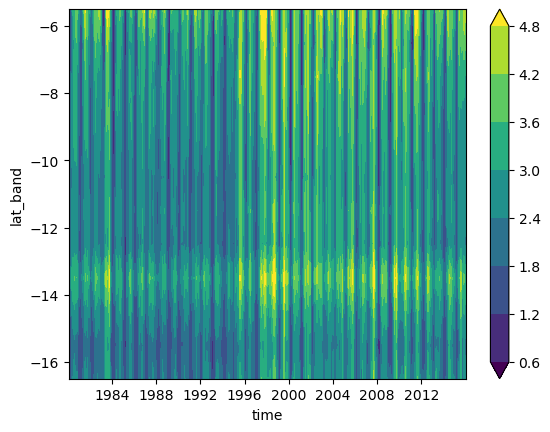

In [20]:
U_ek.plot.contourf(robust=True)

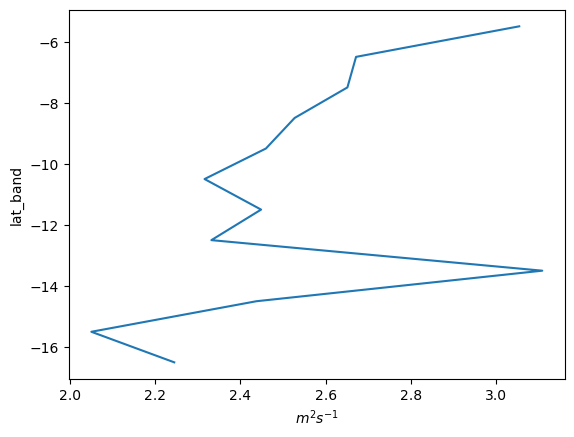

In [21]:
U_ek.mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')

In [22]:
# Qdiv_Sv.plot.contourf(robust=True)

Text(0.5, 1.0, 'Seasonal $U_{Ek}$')

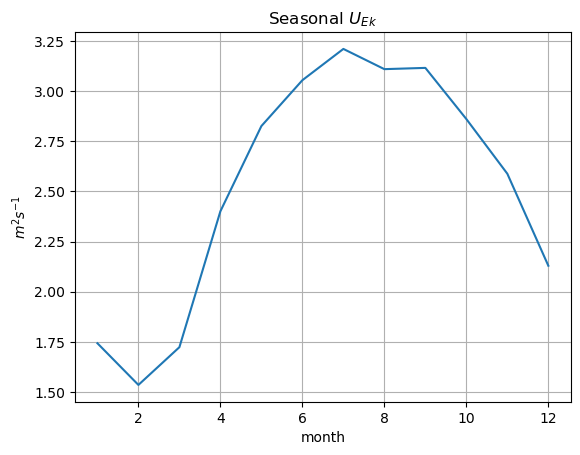

In [23]:
seasonality(U_ek).mean('lat_band').rename('$m^{2}s^{-1}$').plot()
plt.grid()
plt.title('Seasonal $U_{Ek}$')

### Inclusion of the $U^{Geo}$

$
u_{\mathrm{geo}} = \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}
$

$
\mathbf{U}_{\mathrm{geo}} = \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}
$

#### SSH

In [24]:
SSH = loadmat("../../NHCS/Processed/SST_SSH.mat")

time = pd.date_range(start="1980-01",end="2016-01",freq='M')
ds_SSH = xr.Dataset(
    data_vars={
        'SSH':(("time", "lat","lon"), SSH['SSH'].transpose(2, 1, 0)*expanded_mask),
        
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)
ds_SSH

/tmp/ipykernel_381119/1752186948.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    SSH      (time, lat, lon) float64 1GB 0.212 0.212 0.2117 ... nan nan nan

In [25]:
SSHc_ = (ds_SSH.SSH*inshore_mask)

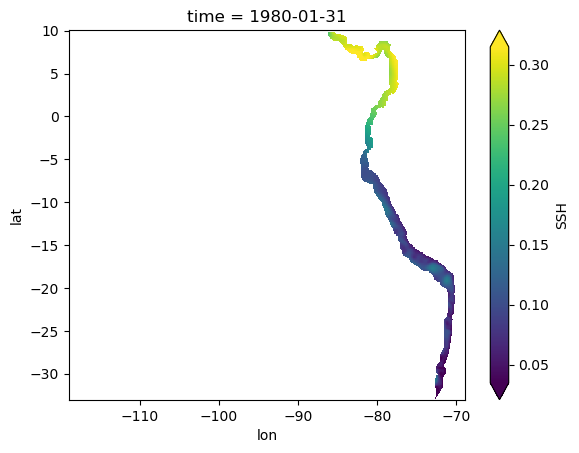

In [26]:
SSHc_.isel(time=0).plot(robust=True)

In [27]:
SSH_ = SSHc_.sel(lat=slice(-17,-5),lon=slice(-83,-70))

lat_top_start = -5   # first northern edge
lat_top_end   = -16  # last northern edge

delta_SSH = []
# results_Sv = []

for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):  # -4, -5, ..., -16
    lat_south = lat_north - 1                                # -5, -6, ..., -17

    # 1° band slice
    SSH_band = SSH_.sel(lat=slice(lat_south, lat_north))

    southernmost = SSH_band.min(dim='lat', skipna=True)
    northernmost = SSH_band.max(dim='lat', skipna=True)
    
    delta_SSH.append(northernmost-southernmost)

ssh = xr.concat(delta_SSH, dim='lat_band')
ssh = ssh.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5 - 1, -1)
)


100%|███████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 340.49it/s]


In [28]:
ssh

<xarray.DataArray 'SSH' (lat_band: 12, time: 432, lon: 156)> Size: 6MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon       (lon) float64 1kB -82.95 -82.87 -82.78 ... -70.2 -70.12 -70.03
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5

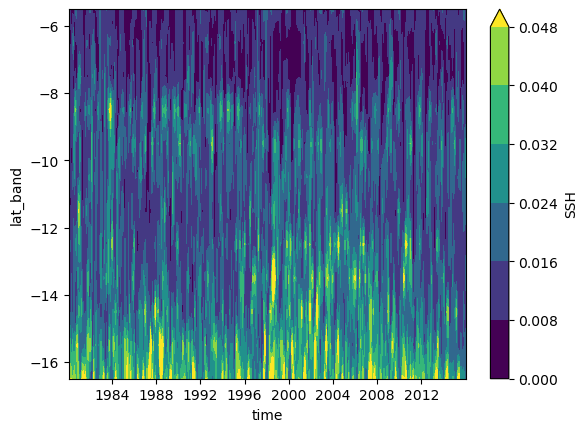

In [29]:
ssh.mean(dim='lon').plot.contourf(robust=True)

In [30]:
lat_top_start = -5   # first northern edge
lat_top_end   = -16  # last northern edge

delta_f = []
# results_Sv = []

for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):  # -4, -5, ..., -16
    lat_south = lat_north - 1                                # -5, -6, ..., -17

    # 1° band slice
    f_band = f.sel(lat=slice(lat_south, lat_north))

    southernmost = f_band.min(dim='lat', skipna=True)
    northernmost = f_band.max(dim='lat', skipna=True)
    
    delta_f.append((northernmost+southernmost)/2)

f_ = xr.concat(delta_f, dim='lat_band')
f_ = f_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5 - 1, -1)
)

100%|██████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 2036.89it/s]


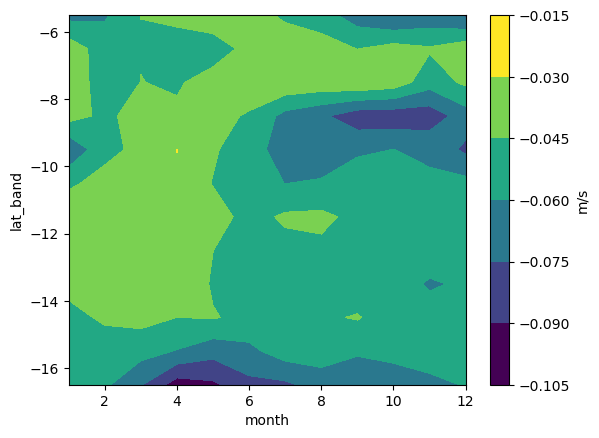

In [31]:
d_coast = 111000#1 grado de latitud en m
g = 9.81

u_geo = (g/f_)*(ssh/d_coast)
#u_geo = u_geo.mean(dim='lon')

#u_geo.plot.contourf(robust=True)

seasonality(u_geo.mean('lon').rename('m/s')).plot.contourf()

#### MLD

In [58]:
MLD = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

MLD_ds = xr.Dataset(
    data_vars={
        'MLD': (("time", "lat","lon"), MLD['MLD'].transpose(2, 1, 0)*expanded_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

MLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan

In [99]:
##MLD mask for 30km
from scipy.ndimage import binary_erosion, binary_dilation

valid2d = np.isfinite(MLD_ds.MLD.mean(dim='time')).astype(bool)

# Coastline mask (valid cells adjacent to NaNs)
eroded = binary_erosion(valid2d, structure=np.ones((3,3)), iterations=1)
coast = valid2d & (~eroded)

# Dilate 3 or 4 times to get ~30 km band
iterations = 3  # adjust as needed

band_mask = binary_dilation(coast, structure=np.ones((3,3)), iterations=iterations) & valid2d

# Convert to DataArray
coords = {'lat': MLD_ds['lat'], 'lon': MLD_ds['lon']}
da_band = xr.DataArray(band_mask, dims=('lat', 'lon'), coords=coords)

# Apply mask to MLD (broadcasts over time)
MLD_30km_band = MLD_ds.MLD.where(da_band) #MLD_30km_band

In [100]:
mld = (MLD_30km_band).sel(lat=slice(-17,-5),lon=slice(-83,-65))
mld

<xarray.DataArray 'MLD' (time: 432, lat: 147, lon: 170)> Size: 86MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon      (lon) float64 1kB -82.95 -82.87 -82.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -5.242 -5.159 -5.076
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

In [101]:
# mld = (MLD_ds*mld_30km_mask).MLD
# mld.isel(time=0).plot()

In [102]:
lat_top_start = -5   # first northern edge
lat_top_end   = -16  # last northern edge

delta_mld = []
# results_Sv = []

for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):  # -4, -5, ..., -16
    lat_south = lat_north - 1                                # -5, -6, ..., -17

    # 1° band slice
    mld_band = mld.sel(lat=slice(lat_south, lat_north))

    southernmost = mld_band.min(dim='lat', skipna=True)
    northernmost = mld_band.max(dim='lat', skipna=True)
    
    delta_mld.append(northernmost-southernmost)

mld_ = xr.concat(delta_mld, dim='lat_band')
mld_ = mld_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5 - 1, -1)
)

100%|███████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 308.28it/s]


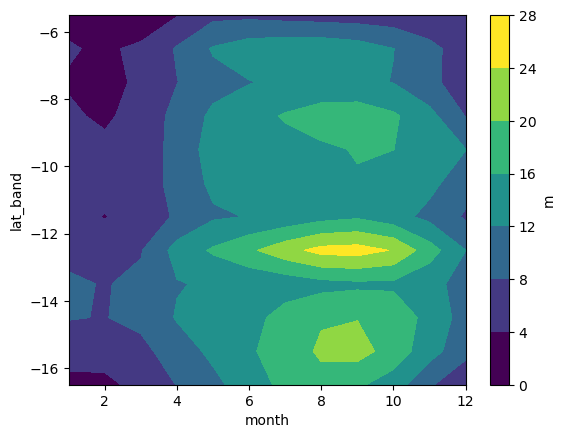

In [103]:
#mld_.mean(dim='lon',skipna=True).plot.contourf(robust=True)
seasonality(mld_.mean(dim=('lon')).rename('m')).plot.contourf()

#### $U^{geo}$

Text(0.5, 1.0, '$U^{Geo}$')

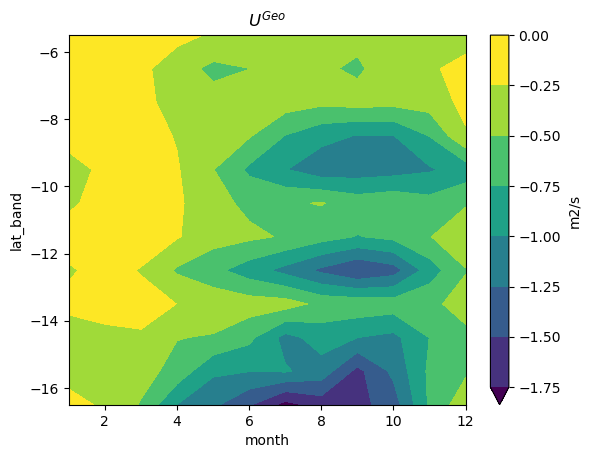

In [104]:
U_geo = (u_geo * mld_)
seasonality((u_geo * mld_).mean(dim='lon')).rename('m2/s').plot.contourf(robust=True)
plt.title('$U^{Geo}$')

The Ugeo points offshore and 

## CUTI

$CUTI$ = $U^{Ek}$ + $U^{Geo}$

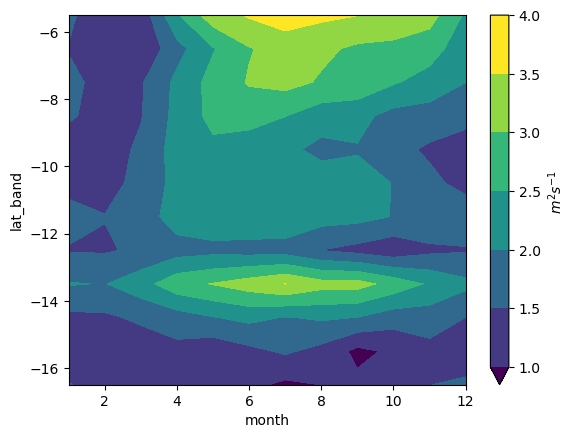

In [105]:
CUTI = U_ek + (U_geo)#m2/s

seasonality(CUTI.mean(dim='lon')).rename('$m^2s^{-1}$').plot.contourf(robust=True)

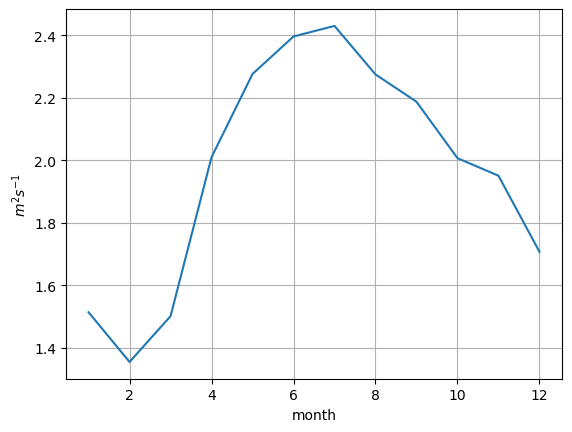

In [106]:
seasonality(CUTI.mean(dim='lon')).mean(dim='lat_band').rename('$m^2s^{-1}$').plot()
plt.grid()

### Jacox et al., 2018 like plot

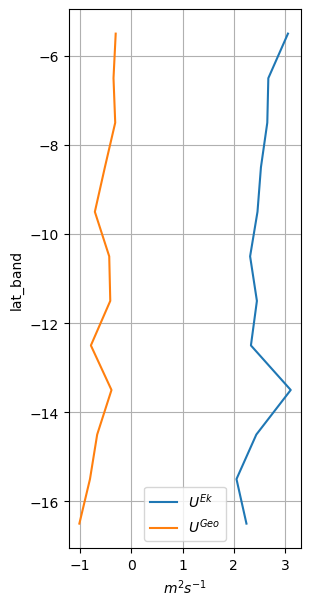

In [107]:
U_ek.mean(dim='time').plot(y='lat_band',figsize=(3,7),label='$U^{Ek}$')
(U_geo).mean(dim=('lon','time')).plot(y='lat_band',label='$U^{Geo}$')
plt.grid()
plt.xlabel('$m^2s^{-1}$')
plt.legend()

Text(0.5, 1.0, 'CUTI components')

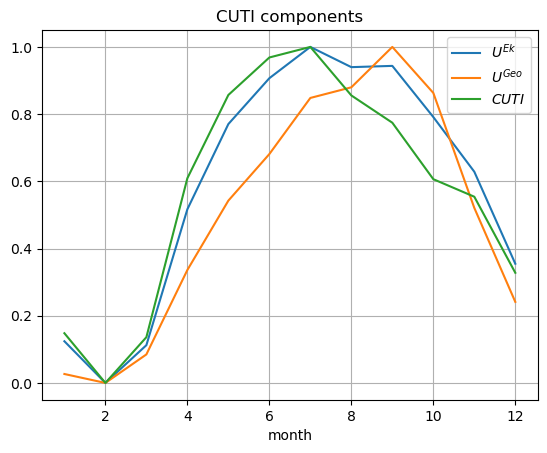

In [108]:
normalize(seasonality(U_ek).mean('lat_band')).plot(label='$U^{Ek}$')
normalize(seasonality(U_geo * -1).mean(dim=('lat_band','lon'))).plot(label='$U^{Geo}$')
normalize(seasonality(CUTI.mean(dim='lon')).mean('lat_band')).plot(label='$CUTI$')
plt.legend()
plt.grid()
plt.title('CUTI components')

Month  1: UGEO   11.3% | Ekman   88.7% | Total=1.97
Month  2: UGEO   11.6% | Ekman   88.4% | Total=1.74
Month  3: UGEO   13.6% | Ekman   86.4% | Total=2
Month  4: UGEO   16.8% | Ekman   83.2% | Total=2.89
Month  5: UGEO   18.9% | Ekman   81.1% | Total=3.48
Month  6: UGEO   20.3% | Ekman   79.7% | Total=3.83
Month  7: UGEO   22.2% | Ekman   77.8% | Total=4.13
Month  8: UGEO   23.3% | Ekman   76.7% | Total=4.05
Month  9: UGEO   25.1% | Ekman   74.9% | Total=4.16
Month 10: UGEO   24.5% | Ekman   75.5% | Total=3.79
Month 11: UGEO   19.8% | Ekman   80.2% | Total=3.23
Month 12: UGEO   16.0% | Ekman   84.0% | Total=2.53


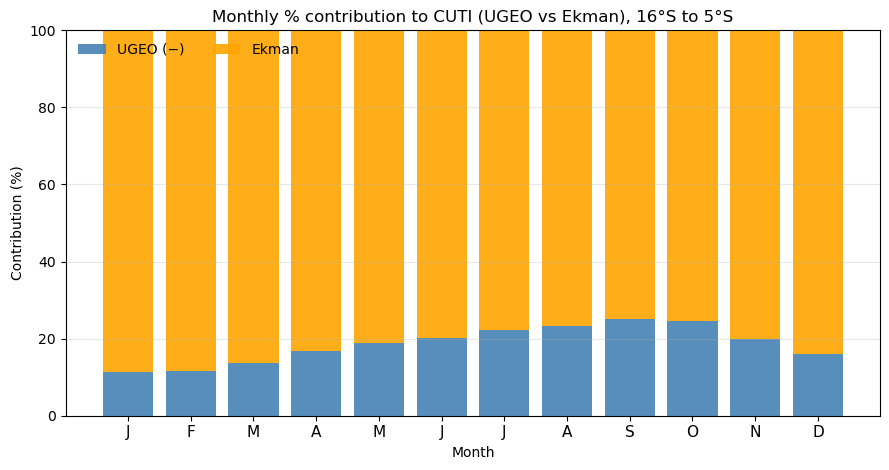

In [109]:
# 1) Build monthly series (as before) and align months
def to_month_1_12(da):
    if 'month' in da.coords:
        m = da['month'].values
        if np.min(m) == 0 and np.max(m) == 11:
            da = da.assign_coords(month=(('month',), m + 1))
        return da
    if 'time' in da.coords:
        return (da.assign_coords(month=da['time'].dt.month)
                  .swap_dims({'time': 'month'})
                  .groupby('month').mean())
    raise ValueError("DataArray needs a 'month' or 'time' coordinate")

months_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
full_months = np.arange(1, 13)

UGEO = seasonality(U_geo*-1).mean(dim=('lat_band','lon'))
EKMN = seasonality(U_ek).mean(dim=('lat_band'))

UGEO = to_month_1_12(UGEO).reindex(month=full_months)
EKMN = to_month_1_12(EKMN).reindex(month=full_months)

u = UGEO.values
e = EKMN.values

# 2) Compute total and percentage contributions
total = u + e
eps = 1e-12  # to avoid division by zero
pct_u = 100 * u / np.where(np.abs(total) < eps, np.nan, total)
pct_e = 100 * e / np.where(np.abs(total) < eps, np.nan, total)

# Optional: handle months with zero/near-zero total (set to 0 instead of NaN)
pct_u = np.where(np.isnan(pct_u), 0.0, pct_u)
pct_e = np.where(np.isnan(pct_e), 0.0, pct_e)

# 3) Print a quick table
for m, pu, pe, tt in zip(full_months, pct_u, pct_e, total):
    print(f"Month {m:2d}: UGEO {pu:6.1f}% | Ekman {pe:6.1f}% | Total={tt:.3g}")

# 4) Plot stacked percent bar chart (100% stacked)
fig, ax = plt.subplots(figsize=(9, 4.8))
x = full_months
width = 0.8

# Split positive/negative totals if you prefer sign-aware; here we show simple 100% stack
ax.bar(x, pct_u, width=width, label='UGEO (−)', color='steelblue', alpha=0.9)
ax.bar(x, pct_e, width=width, bottom=pct_u, label='Ekman', color='orange', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(months_labels, fontsize=11)
ax.set_xlabel('Month')
ax.set_ylabel('Contribution (%)')
ax.set_title('Monthly % contribution to CUTI (UGEO vs Ekman), 16°S to 5°S')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, ncol=2, loc='upper left')

plt.tight_layout()
plt.show()

#### Validation with $W_{mld}$

In [110]:
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")
WMLD_ds = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)*expanded_mask*inshore_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

WMLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    WMLD     (time, lat, lon) float64 1GB nan nan nan nan ... nan nan nan nan

In [112]:
def lat_band_mean(
    f,
    lat_top_start=-5,
    lat_top_end=-16,
):
    """
    Compute (f_north + f_south)/2 for successive 1° latitude bands.

    Parameters
    ----------
    f : xarray.DataArray
        Must have a 'lat' dimension (and optionally time/lon/etc.).
    lat_top_start : float or int
        Northern latitude of the first band (e.g. -5).
    lat_top_end : float or int
        Northern latitude of the last band (e.g. -16).

    Returns
    -------
    f_band : xarray.DataArray
        delta_f for each 1° band, with new dimension 'lat_band'.
        Any other original dimensions (e.g. time) are preserved.
    """

    delta_f = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):
        lat_south = lat_north - 1

        # 1° band slice
        f_band = f.sel(lat=slice(lat_south, lat_north))

        # skip bands with no points
        if f_band.sizes.get("lat", 0) == 0:
            continue

        southernmost = f_band.min(dim="lat", skipna=True)
        northernmost = f_band.max(dim="lat", skipna=True)

        delta_f.append((northernmost + southernmost) / 2)
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # concat over bands
    f_out = xr.concat(delta_f, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))
    f_out.name = "delta_f"

    return f_out

In [120]:
wmld = lat_band_mean(WMLD_ds.WMLD,
    lat_top_start=-5,
    lat_top_end=-16,
)

100%|███████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 130.07it/s]


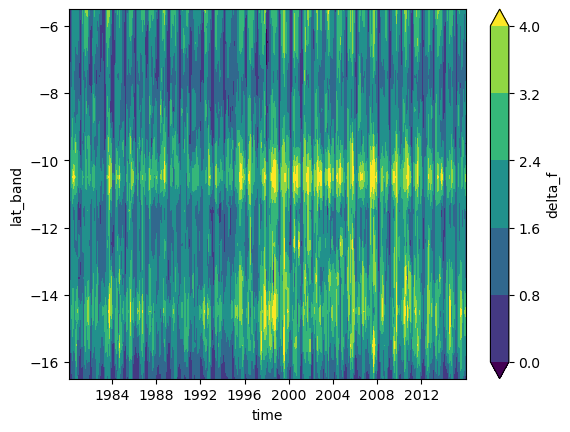

In [138]:
(wmld*111e3).mean('lon').plot.contourf(y='lat_band',robust=True)

### CUTI and $W_{mld}$ comparison

Text(0.5, 1.0, 'RM=13')

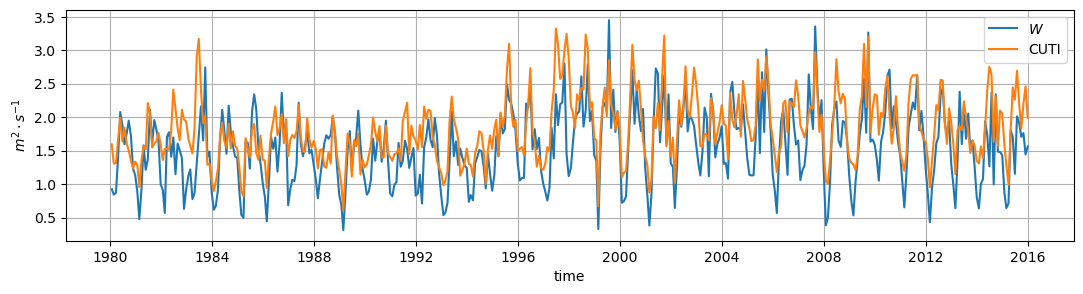

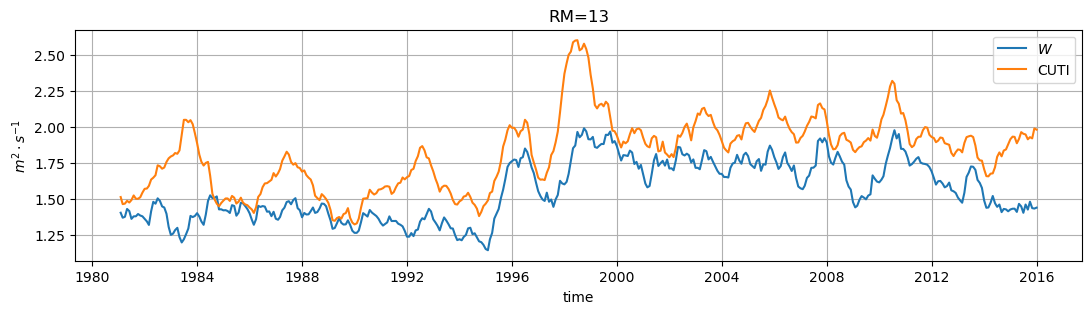

In [154]:
(wmld*111e3).mean(dim=('lon','lat_band')).plot(figsize=(13,3),label='$W$')
CUTI.mean(dim=('lon','lat_band')).rename('$m^{2} \cdot s^{-1}$').plot(label='CUTI')
plt.grid()
plt.legend()


(wmld*111e3).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(figsize=(13,3),label='$W$')
CUTI.mean(dim=('lon','lat_band')).rolling(time=13).mean().rename('$m^{2} \cdot s^{-1}$').plot(label='CUTI')
plt.grid()
plt.legend()
plt.title('RM=13')